LR
Accuracy: 0.8521400778210116
Precision: 0.8263888888888888
Recall: 0.9015151515151515
F1: 0.8623188405797102
AUC: 0.9227272727272726

SVM
Accuracy: 0.6926070038910506
Precision: 0.6992481203007519
Recall: 0.7045454545454546
F1: 0.7018867924528301
AUC: 0.7483030303030304

RF
Accuracy: 0.9883268482490273
Precision: 0.9777777777777777
Recall: 1.0
F1: 0.9887640449438202
AUC: 0.9999999999999999



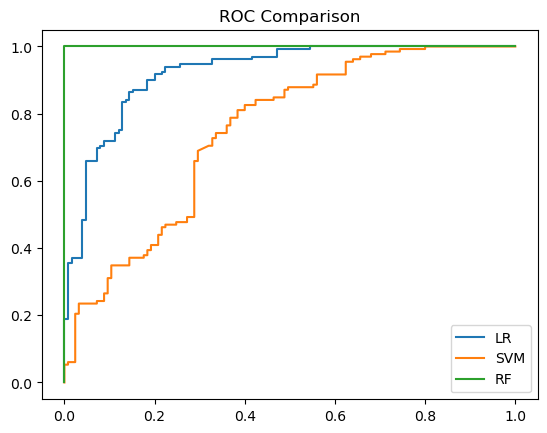

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve
# Dataset
df = pd.read_csv("heart.csv")
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

models = {
    "LR": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf', probability=True),
    "RF": RandomForestClassifier()
}

plt.figure()

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_prob))
    print()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Comparison")
plt.show()